# Planet to planet low-thrust

In this tutorial we show the use of the {class}`pykep.trajopt.direct_pl2pl` to find a low-thrust trajectory connecting two moving planets. 

The decision vector for this class, compatible with pygmo {cite:p}`pagmo` UDPs (User Defined Problems), is:

$$
\mathbf x = [t_0, m_f, V_{sx}^\infty, V^\infty_{sy}, V^\infty_{sz}, V^\infty_{fx}, V^\infty_{fy}, V^\infty_{fz}, u_{x0}, u_{y0}, u_{z0}, u_{x1}, u_{y1}, u_{z1}, ..., T_{tof}]
$$

containing the starting epoch $t_0$ as a MJD2000, the final mass $m_f$ as well as the starting and final $V^{\infty}$, throttles and the time-of-flight $T_{tof}$.

:::{note}
This notebook makes use of the commercial solver SNOPT 7 and to run needs a valid `snopt_7_c` library installed in the system. In case SNOPT7 is not available, you can still run the notebook using, for example `uda = pg.algorithm.nlopt("slsqp")` with minor modifications.

Basic imports:

In [18]:
import pykep as pk
import numpy as np
import time
import pygmo as pg
import pygmo_plugins_nonfree as ppnf
import time

from matplotlib import pyplot as plt

We start defining the problem data.

In [19]:
# Problem data
mu = pk.MU_SUN
max_thrust = 0.6
isp = 3000
tof = 250.0

posvel0 = [
    [34110913367.783306, -139910016918.87585, -14037825669.025244],
    [29090.9902134693, 10000.390168313803, 1003.3858682643288],
]
posvelf = [
    [-159018773159.22266, -18832495968.945133, 15781467087.350443],
    [2781.182556622003, -28898.40730995848, -483.4533989771214],
]

# Define initial and target
p1 = pk.planet(pk.udpla.keplerian(when=pk.epoch(0), posvel = posvel0, mu_central_body=mu))
p2 = pk.planet(pk.udpla.keplerian(when=pk.epoch(tof), posvel = posvelf, mu_central_body=mu))

# Initial state
ms = 1500.0

# Number of segments
nseg = 16

We here instantiate two different versions of the same UDP (User Defined Problem), with analytical gradients and without. 

For the purpose of this simple notebook we choose a relatively simple Earth to Mars transfer with an initial $V_{\infty}$ of 3 km/s.

In [20]:
udp_g = pk.trajopt.direct_pl2pl(
        pls=p1,
        plf=p2,
        ms=ms,
        mu=mu,
        max_thrust=max_thrust,
        isp=isp,
        t0_bounds=[0.0, 0.0],
        tof_bounds=[tof,tof],
        mf_bounds=[ms*0.5, ms],
        vinfs=0.,
        vinff=0.,
        nseg=nseg,
        cut=0.6,
        mass_scaling=ms,
        r_scaling=pk.AU,
        v_scaling=pk.EARTH_VELOCITY,
        with_gradient=False,
        high_fidelity=True
)

## Analytical performances of the analytical gradient

And we take a quick look at the performances of the analytical gradient with respect to the numerically computed one.

In [21]:
# We need to generste a random chromosomes compatible with the UDP where to test the gradient.
prob_g = pg.problem(udp_g)
pop_g = pg.population(prob_g, 1)

First the analytical gradient:

In [22]:
# %%timeit
# udp_g.gradient(pop_g.champion_x)

Then a simple numerical gradient based on finite differences:

In [23]:
# %%timeit
# pg.estimate_gradient(udp_g.fitness, pop_g.champion_x)

Then a higher order numerical gradient:

In [24]:
# %%timeit
# pg.estimate_gradient_h(udp_g.fitness, pop_g.champion_x)

The analytical gradient its exact and faster, seems like a no brainer to use it. 

In reality, the effects on the optimization technique used are not straightforward, making the option to use numerical gradients still interesting in some, albeit rare, cases.

## Solving the low-thrust transfer

We define (again) the optimization problem, and set a tolerance for *pagmo* to be able to judge the relative value of two individuals. 

:::{note}
This tolerance has a different role from the numerical tolerance set in the particular algorithm chosen to solve the problem and is only used by the *pagmo* machinery to decide outside the optimizer whether the new proposed indivdual is better than what was the previous *champion*.

In [25]:
prob_g = pg.problem(udp_g)
prob_g.c_tol = 1e-6

... and we define an optimization algorithm.

In [26]:
snopt72 = "/Users/harry.holt/opt/libsnopt7_c.dylib"
uda = ppnf.snopt7(library=snopt72, minor_version=2, screen_output=False)
uda.set_integer_option("Major iterations limit", 2000)
uda.set_integer_option("Iterations limit", 20000)
uda.set_numeric_option("Major optimality tolerance", 1e-3)
uda.set_numeric_option("Major feasibility tolerance", 1e-11)

algo = pg.algorithm(uda)

In [27]:
# uda = pg.nlopt("slsqp")
# algo = pg.algorithm(uda)

In [28]:
# ip = pg.ipopt()
# ip.set_numeric_option("tol", 1E-9) # Change the relative convergence tolerance
# ip.set_integer_option("max_iter", 500) # Change the maximum iterations
# ip.set_integer_option("print_level", 0) # Makes Ipopt unverbose
# ip.set_string_option("nlp_scaling_method", "none") # Removes any scaling made in auto mode
# ip.set_string_option("mu_strategy", "adaptive") # Alternative is to tune the initial mu value
# algo = pg.algorithm(ip)

We solve the problem from random initial guess ten times and only save the result if a feasible solution is found (as defined by the criterias above)

In [29]:
masses = []
xs = []
for i in range(20):
    pop_g = pg.population(prob_g, 1)
    pop_g = algo.evolve(pop_g)
    if(prob_g.feasibility_f(pop_g.champion_f)):
        print(".", end="")
        masses.append(pop_g.champion_x[1])
        xs.append(pop_g.champion_x)
        # break
    else:
        print("x", end ="")
print("\nBest mass is: ", np.max(masses))
print("Worst mass is: ", np.min(masses))
best_idx = np.argmax(masses)

x.x.xxx..xx.xx.x..x.
Best mass is:  1258.9906408786417
Worst mass is:  1258.902634285033


And we plot the trajectory found:

In [30]:
udp_g.pretty(xs[best_idx])


Low-thrust NEP transfer
Departure: unknown UDPLA
Arrival: unknown UDPLA

Launch epoch: 0.00000 MJD2000, a.k.a. 2000-01-01T00:00:00.000000
Arrival epoch: 250.00000 MJD2000, a.k.a. 2000-09-07T00:00:00.000000
Time of flight (days): 250.00000 

Launch DV (km/s) 0.00000000 - [0.0,0.0,0.0]
Arrival DV (km/s) 0.00000000 - [0.0,0.0,0.0]
Final mass (kg): 1258.9906408786417

Details on the low-thrust leg: 
Number of segments: 16
Number of fwd segments: 9
Number of bck segments: 7
Maximum thrust: 0.6
Central body gravitational parameter: 1.3271244004127942e+20
Specific impulse: 3000

Time of flight: 21600000
Initial mass: 1500
Final mass: 1258.9906408786417
State at departure: [[34110913367.783306, -139910016918.87585, -14037825669.025244], [29090.9902134693, 10000.390168313803, 1003.3858682643288]]
State at arrival: [[-159018773159.22266, -18832495968.945133, 15781467087.350443], [2781.182556622003, -28898.40730995848, -483.4533989771214]]
Throttles values: [-0.07598305964077015, 0.0406671845909

State History:
state_history_fwd [ 3.41109134e+10 -1.39910017e+11 -1.40378257e+10  2.90909902e+04
  1.00003902e+04  1.00338587e+03  1.50000000e+03] [ 1.22584359e+10  1.44113978e+11  1.12492364e+10 -3.00851551e+04
  5.27411244e+03  1.35789680e+03  1.44103963e+03]
state_history_bck [-1.59018773e+11 -1.88324960e+10  1.57814671e+10  2.78118256e+03
 -2.88984073e+04 -4.83453399e+02  1.25899064e+03] [ 1.22584358e+10  1.44113979e+11  1.12492363e+10 -3.00851551e+04
  5.27411239e+03  1.35789681e+03  1.44104004e+03]


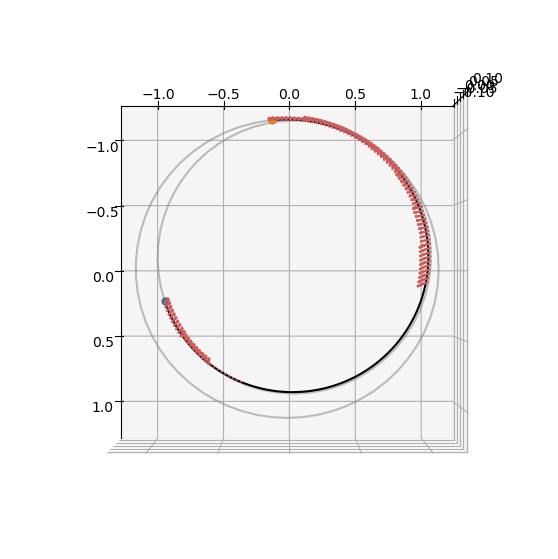

In [31]:
ax = udp_g.plot(xs[best_idx], show_gridpoints=True)
ax.view_init(90, 0)

In [32]:
# Add Alpha Encoding with constant segments
x = xs[best_idx]
np.insert(x,8,np.array([0.7788007830714049]*4))

array([ 0.00000000e+00,  1.25899064e+03,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        7.78800783e-01,  7.78800783e-01,  7.78800783e-01,  7.78800783e-01,
       -7.59830596e-02,  4.06671846e-02, -9.96279802e-01, -7.35829161e-02,
       -2.09313326e-02, -9.97069771e-01, -8.74222657e-03, -1.39274499e-02,
       -1.40527228e-01, -7.42874663e-07, -8.77620741e-07, -1.52239574e-06,
       -4.30159282e-07, -5.39443205e-07, -3.99984802e-07, -1.54056572e-07,
       -4.60430793e-07, -8.87680417e-08,  1.57569561e-08, -4.22166651e-07,
       -3.26736992e-07, -4.48120978e-07, -7.08508370e-08,  1.13440554e-06,
        7.41752579e-07, -1.82980614e-06,  2.74102339e-06,  6.63937379e-02,
       -2.19172490e-01,  5.67755535e-01,  5.54300964e-02, -3.73200569e-01,
        9.26093422e-01,  2.99977213e-02, -4.28726604e-01,  9.02936243e-01,
        3.67493449e-02, -5.13528327e-01,  8.57285398e-01,  8.10198780e-02,
       -6.15282663e-01,  

In [45]:
# Alpha encodings
nseg_tmp = 8
alpha_mid = pk.direct2alpha([1/nseg_tmp]*nseg_tmp)
print(alpha_mid)
print(alpha_mid[0][0] * 0.25)
print(alpha_mid[0][0] * 1.25)

([0.8824969025845955, 0.8824969025845955, 0.8824969025845955, 0.8824969025845955, 0.8824969025845955, 0.8824969025845955, 0.8824969025845955, 0.8824969025845955], 1.0)
0.22062422564614886
1.1031211282307443


In [37]:
alpha_lb

([0.846481724890614,
  0.846481724890614,
  0.846481724890614,
  0.846481724890614,
  0.846481724890614,
  0.846481724890614],
 0.7999999999999999)